02_eda.ipynb
│
├── 1. Ziel und Fragestellungen
├── 2. Daten laden
├── 3. Datenüberblick
├── 4. Datenqualität
├── 5. Deskriptive Statistik
├── 6. Strompreis analysieren
├── 7. Erzeugung und Last analysieren
├── 8. Zeitliche Muster
├── 9. Zusammenhänge und Korrelationen
├── 10. Extreme Preisereignisse
├── 11. Zentrale Erkenntnisse
└── 12. Vorbereitung Feature Engineering

# Explorative Datenanalyse - Deutscher Strommarkt 

## Ziel 

Dieses Notebook untersucht die historischen Strompreis-, Erzeugungs und Lastdaten für Deutschland im Zeitraum 2023 - 2025. 
Ziel dieser Analyse ist es, die wesentlichen Statisitschen Eigenschaften, zeitliche Muster und Zusammenhänge der Daten zu identifizeiren und daraus Anforderungen für die spätere Modellierungder Strompreise abzuleiten. 

### Untersuchungsfragen

1. Wie verteilen sich die deutschen Strompreise?
2. Welche saisonalen und zeitlichen Muster sind erkennbar?
3. Wie verhalten sich Wind-, Solar- und Stromlast?
4. Welche Zusammenhänge bestehen zwischen Strompreis und Energiedaten?
5. Wie häufig treten extreme bzw. negative Strompreise auf?
6. Welche Variablen eignen sich potenziell als Features für die Prognose?

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/energy_hourly_2023_2025.csv"
)

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True
)

df["timestamp"] = df["timestamp"].dt.tz_convert(
    "Europe/Berlin"
)

df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

### Abgrenzung des Untersuchungszeitraums

Für die weitere Analyse wird der Untersuchungszeitraum auf den
01.01.2023 bis zum 31.12.2025 begrenzt. Die über die API abgerufenen
Daten enthalten einen kleinen Anteil an Beobachtungen aus dem Jahr 2026,
die für die Untersuchung nicht berücksichtigt werden.

In [75]:
df["timestamp"].max()
df[df["timestamp"].dt.year == 2026].head()

,timestamp,price,wind_offshore,wind_onshore,solar,load,wind
26304,2026-01-01 00:00:00+01:00,58.2775,3161.900,32304.575,0.000,46122.875,35466.475
26305,2026-01-01 01:00:00+01:00,42.3950,4043.725,33832.675,0.000,45598.250,37876.400
26306,2026-01-01 02:00:00+01:00,19.5700,4889.700,34572.225,0.000,44673.900,39461.925
26307,2026-01-01 03:00:00+01:00,6.2850,5394.400,35688.325,0.000,43796.400,41082.725
26308,2026-01-01 04:00:00+01:00,3.0925,5326.075,36182.700,5.925,43359.550,41508.775


In [76]:
df = df[
    (df["timestamp"].dt.year >= 2023) &
    (df["timestamp"].dt.year <= 2025)
].copy()

In [77]:
print("Start:", df["timestamp"].min())
print("Ende:", df["timestamp"].max())
print("Anzahl Beobachtungen:", len(df))

Start: 2023-01-01 00:00:00+01:00
Ende: 2025-12-31 23:00:00+01:00
Anzahl Beobachtungen: 26304


In [78]:
df.tail()

,timestamp,price,wind_offshore,wind_onshore,solar,load,wind
26299,2025-12-31 19:00:00+01:00,95.9900,5702.100,26991.075,17.675,55505.600,32693.175
26300,2025-12-31 20:00:00+01:00,86.8025,5285.150,28125.750,15.500,52297.325,33410.900
26301,2025-12-31 21:00:00+01:00,79.7975,4674.250,29955.525,11.525,50355.325,34629.775
26302,2025-12-31 22:00:00+01:00,81.3900,3593.325,29830.400,0.000,49025.550,33423.725
26303,2025-12-31 23:00:00+01:00,76.4475,2988.675,31089.325,0.000,47434.625,34078.000


In [79]:
print(df.shape)
print(df.dtypes)
print(df["timestamp"].min())
print(df["timestamp"].max())

(26304, 7)
timestamp        datetime64[us, Europe/Berlin]
price                                  float64
wind_offshore                          float64
wind_onshore                           float64
solar                                  float64
load                                   float64
wind                                   float64
dtype: object
2023-01-01 00:00:00+01:00
2025-12-31 23:00:00+01:00


# Datenüberblick
womit arbeiten wir 

In [80]:
print("Anzahl Beobachtungen:", len(df))
print("Anzahl Variablen:", len(df.columns))
print("Shape:",df.shape)
print("Spaltennamen:",df.columns.tolist())

Anzahl Beobachtungen: 26304
Anzahl Variablen: 7
Shape: (26304, 7)
Spaltennamen: ['timestamp', 'price', 'wind_offshore', 'wind_onshore', 'solar', 'load', 'wind']


# Datenqualität

In [81]:
print("Missing Values:",df.isna().sum())
print("Duplicates:", df["timestamp"].duplicated().sum())
print("Time intervalls:",df["timestamp"].diff().value_counts().head())
print("Start:", df["timestamp"].min())
print("Ende:", df["timestamp"].max())

Missing Values: timestamp        0
price            0
wind_offshore    0
wind_onshore     0
solar            0
load             0
wind             0
dtype: int64
Duplicates: 0
Time intervalls: timestamp
0 days 01:00:00    26303
Name: count, dtype: int64
Start: 2023-01-01 00:00:00+01:00
Ende: 2025-12-31 23:00:00+01:00


# Deskriptive Statistik

In [82]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,26304.0,87.66,51.32,-500.00,65.06,90.06,112.97,936.28
wind_offshore,26304.0,2862.04,1931.84,0.00,1126.60,2612.06,4472.93,8237.78
wind_onshore,26304.0,12608.08,9723.72,45.82,4850.71,10014.92,18262.38,47795.28
solar,26304.0,6985.15,10656.76,0.00,0.60,227.34,11262.75,49713.88
load,26304.0,52832.35,9131.09,30902.68,45328.97,52882.55,59712.74,75635.23
wind,26304.0,15470.12,10975.65,45.85,6444.69,12909.40,22494.91,52173.80


In [83]:
price_stats = df["price"].describe()

price_stats.round(2)

count    26304.00
mean        87.66
std         51.32
min       -500.00
25%         65.06
50%         90.06
75%        112.97
max        936.28
Name: price, dtype: float64

# Strompreisverteilung

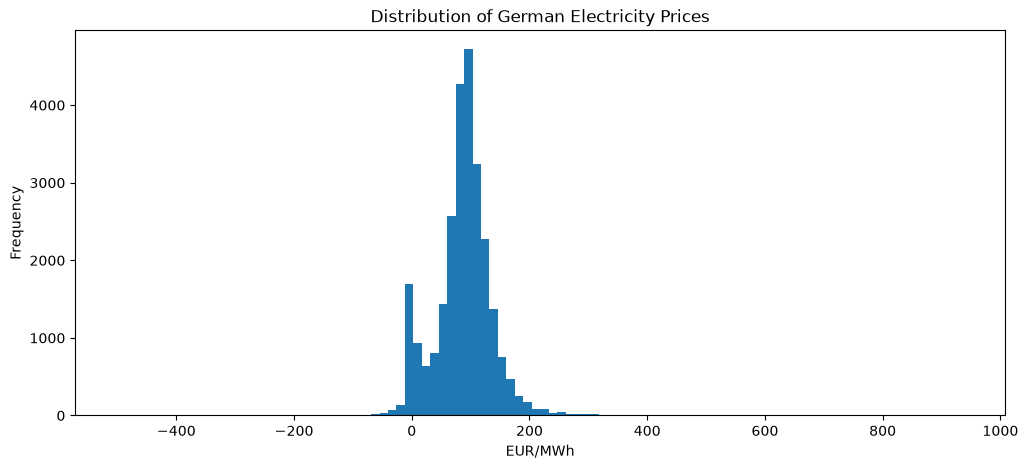

In [84]:
plt.figure(figsize=(12, 5))

plt.hist(
    df["price"],
    bins=100
)

plt.title("Distribution of German Electricity Prices")
plt.xlabel("EUR/MWh")
plt.ylabel("Frequency")

plt.show()

Preisverteilung ist nicht symetrisch und weißt positive , sowie negative Preiswerte auf. 
Die Strompreise weisen eine erhebliche Streuung auf. Besonders auffällig ist die große Spannbreite, von -500EURO/MWh für den minimalen Preis bis zu einem Maximalen Preis von 936,29 EUR/MWh. 

# Boxplot

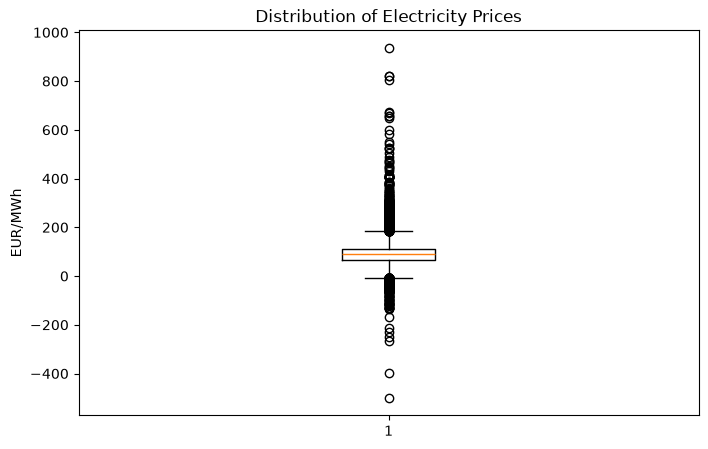

In [85]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["price"].dropna())

plt.title("Distribution of Electricity Prices")
plt.ylabel("EUR/MWh")

plt.show()

# Strompreis 

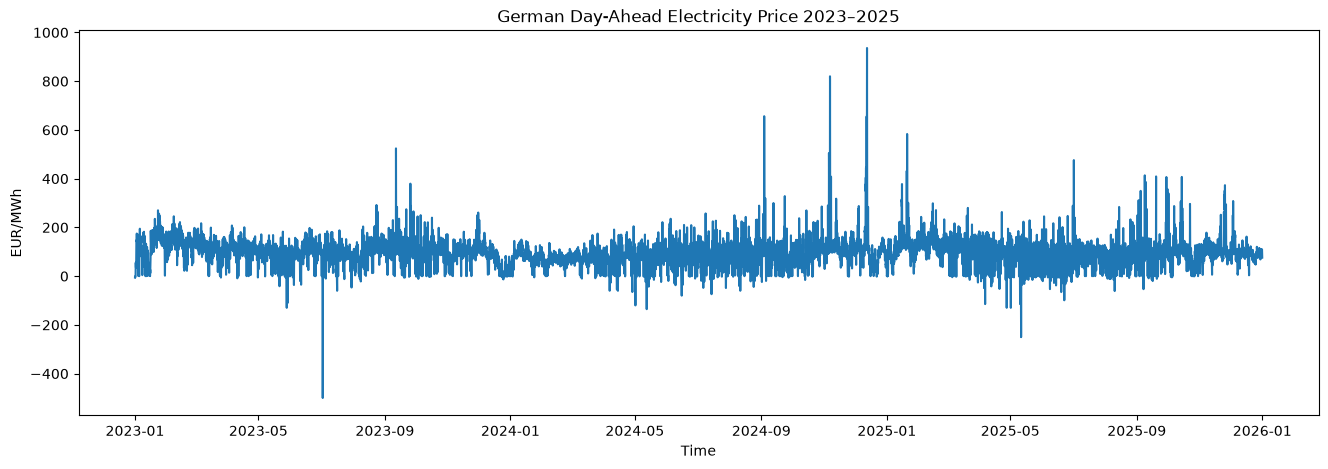

In [86]:
plt.figure(figsize=(16, 5))

plt.plot(
    df["timestamp"],
    df["price"]
)

plt.title("German Day-Ahead Electricity Price 2023–2025")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")

plt.show()

# Vergleich, Preis pro Jahr 

In [87]:
df["year"] = df["timestamp"].dt.year

In [88]:
df.groupby("year")["price"].agg(
    ["mean", "std", "min", "max"]
).round(2)

,mean,std,min,max
year,,,,
2023,95.18,47.58,-500.00,524.27
2024,78.51,52.73,-135.45,936.28
2025,89.32,52.10,-250.32,583.40


Das durchschnittliche Preisniveaus unterscheidet sich erheblich in den 2 JAhren, währen die Standardabweichung relativkonstant bleibt. 

# Negative Strompreise 

In [89]:
negative_prices = df[df["price"] < 0]

print(
    "Anzahl negativer Preise:",
    len(negative_prices)
)

Anzahl negativer Preise: 1334


In [90]:
print(
    "Anteil negativer Preise:",
    len(negative_prices) / len(df)
)

Anteil negativer Preise: 0.0507147201946472


In [91]:
df.groupby("year").apply(
    lambda x: (x["price"] < 0).mean()
)

year
2023    0.034361
2024    0.052026
2025    0.065753
dtype: float64

 Der Anteil negativer Preise hat sich in dem Untersuchungszeitraum deutlcih erhöht. Negative Preise stellen daher in dem Datensatz keinen Einzelfall dar, sondern treten wiederholt auf. 
 Für eine spätere Prognose ist daher sicherzustellen, dass das verwendete
Modell negative Preise grundsätzlich abbilden kann.

# Wind und Solar 

In [92]:
df[[
    "wind",
    "solar"
]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
wind,26304.0,15470.12,10975.65,45.85,6444.69,12909.40,22494.91,52173.80
solar,26304.0,6985.15,10656.76,0.00,0.60,227.34,11262.75,49713.88


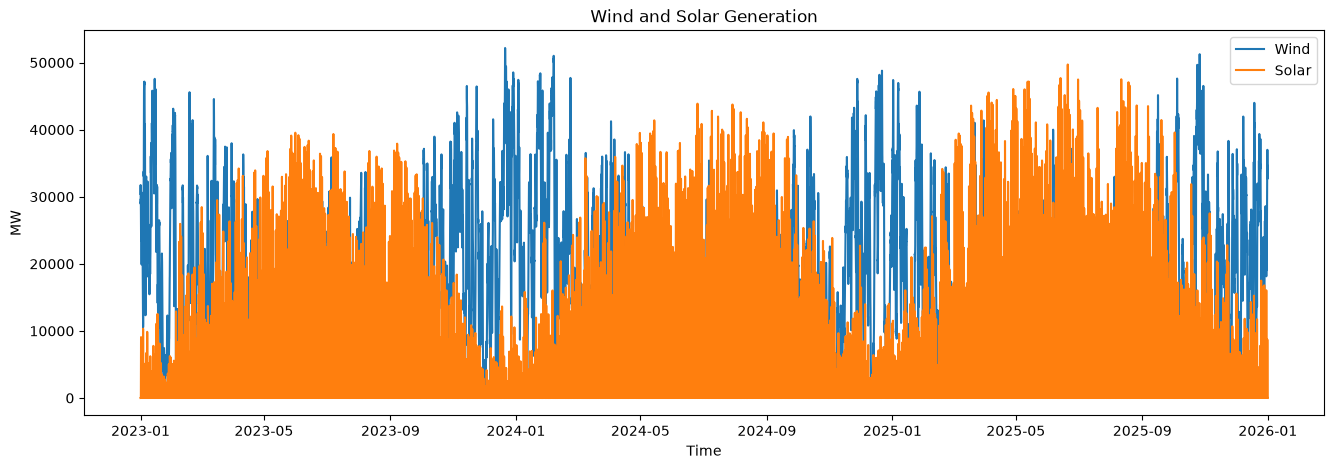

In [93]:
plt.figure(figsize=(16, 5))

plt.plot(
    df["timestamp"],
    df["wind"],
    label="Wind"
)

plt.plot(
    df["timestamp"],
    df["solar"],
    label="Solar"
)

plt.title("Wind and Solar Generation")
plt.xlabel("Time")
plt.ylabel("MW")

plt.legend()

plt.show()

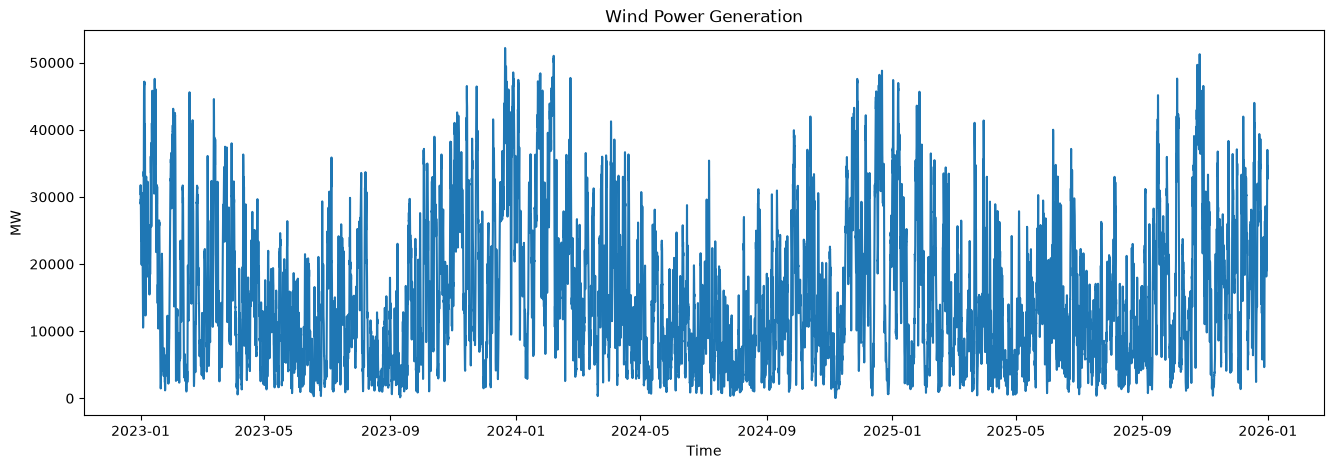

In [112]:
plt.figure(figsize=(16, 5))

plt.plot(
    df["timestamp"],
    df["wind"]
)

plt.title("Wind Power Generation")
plt.xlabel("Time")
plt.ylabel("MW")

plt.show()

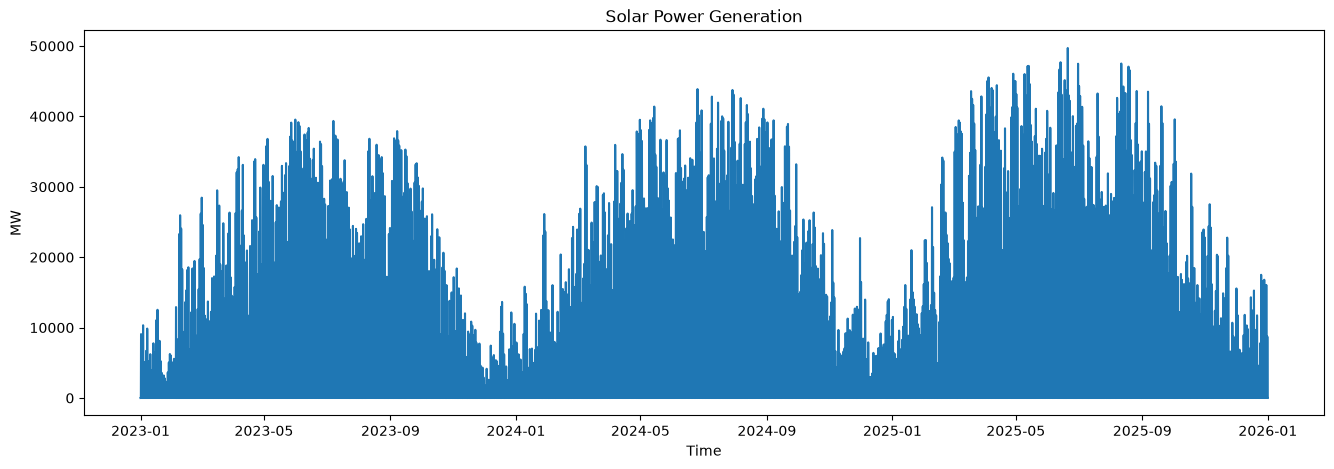

In [113]:
plt.figure(figsize=(16, 5))

plt.plot(
    df["timestamp"],
    df["solar"]
)

plt.title("Solar Power Generation")
plt.xlabel("Time")
plt.ylabel("MW")

plt.show()

# Wind -und Solar Stromerzeugung für eine Woche 

In [114]:
week = df[
    (df["timestamp"] >= "2025-06-01") &
    (df["timestamp"] < "2025-06-08")
]

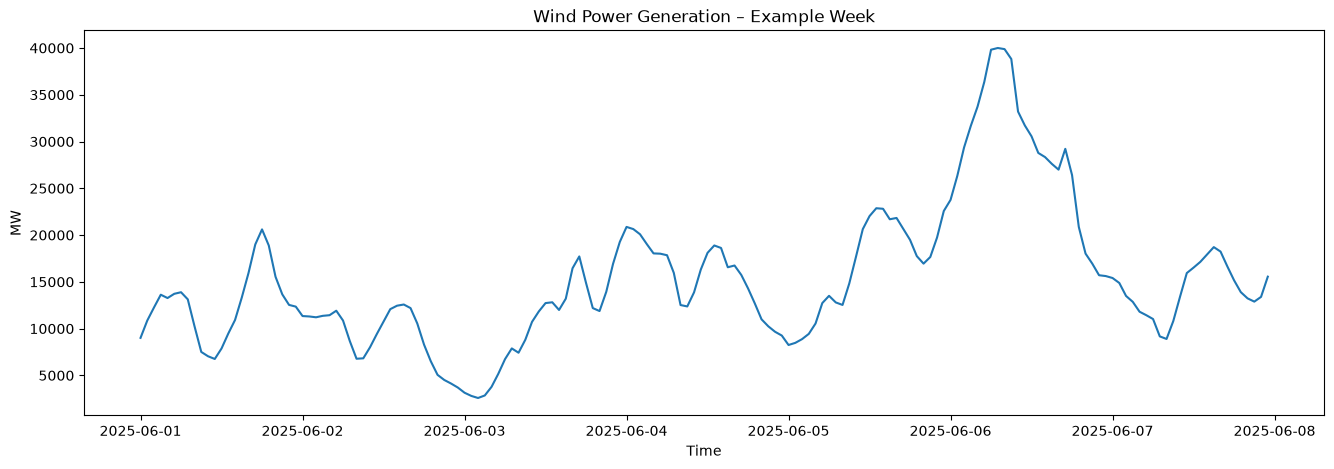

In [115]:
plt.figure(figsize=(16, 5))

plt.plot(
    week["timestamp"],
    week["wind"]
)

plt.title("Wind Power Generation – Example Week")
plt.xlabel("Time")
plt.ylabel("MW")

plt.show()

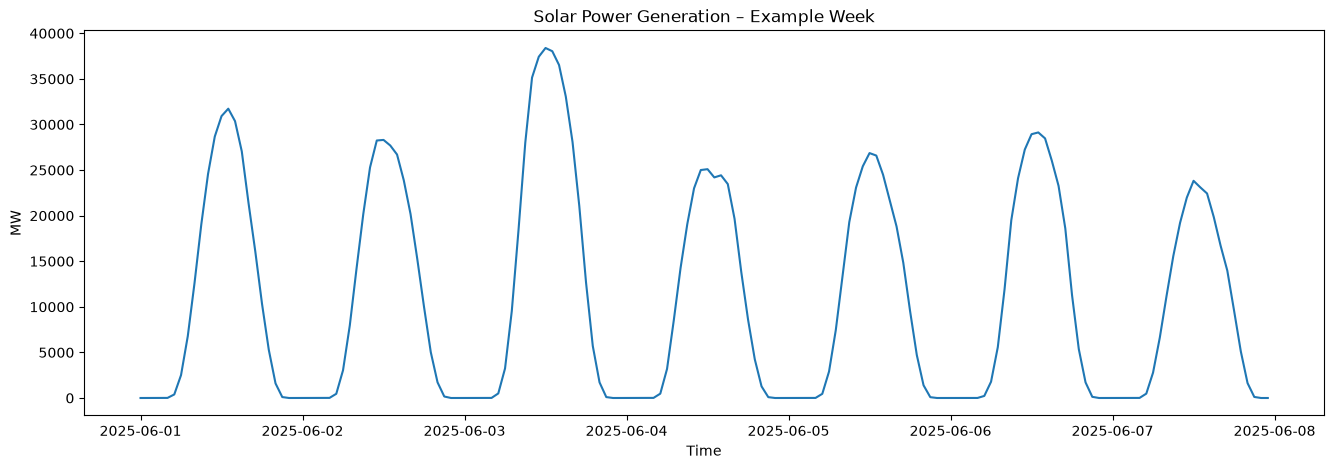

In [116]:
plt.figure(figsize=(16, 5))

plt.plot(
    week["timestamp"],
    week["solar"]
)

plt.title("Solar Power Generation – Example Week")
plt.xlabel("Time")
plt.ylabel("MW")

plt.show()

# Load analysieren 

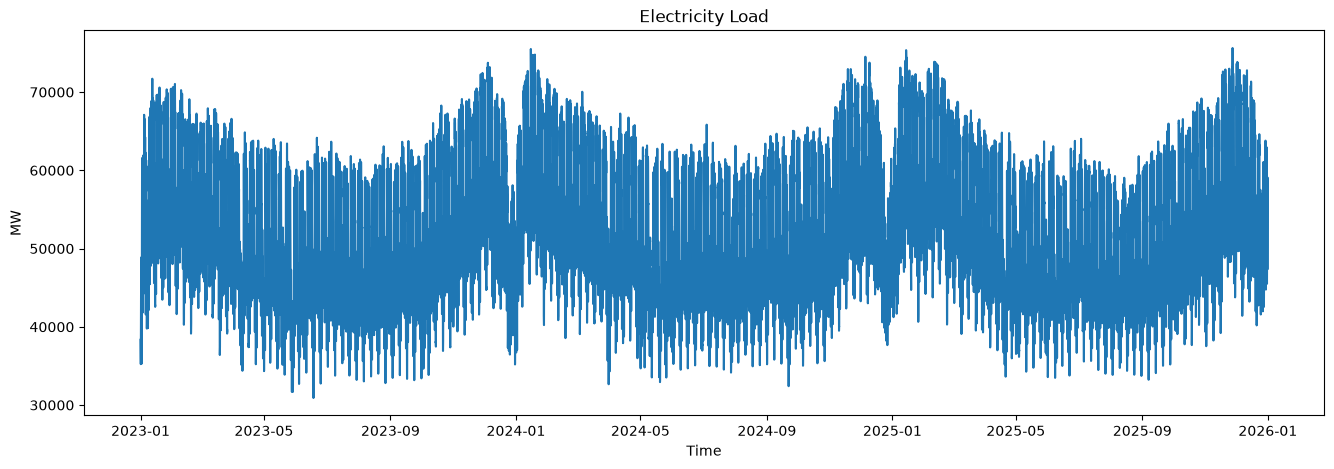

In [94]:
plt.figure(figsize=(16, 5))

plt.plot(
    df["timestamp"],
    df["load"]
)

plt.title("Electricity Load")
plt.xlabel("Time")
plt.ylabel("MW")

plt.show()

# Tageszeit analsieren 

##  Tagesprofil eines Strompreises

In [95]:
df["hour"] = df["timestamp"].dt.hour

In [96]:
hourly_price = (
    df.groupby("hour")["price"]
    .mean()
)

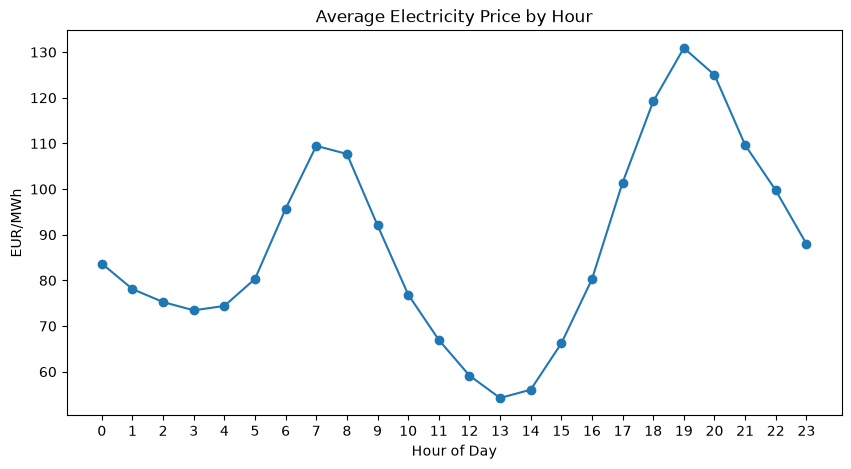

In [97]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_price.index,
    hourly_price.values,
    marker="o"
)

plt.title("Average Electricity Price by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("EUR/MWh")

plt.xticks(range(24))

plt.show()

# Wochentage 

In [98]:
df["weekday"] = df["timestamp"].dt.dayofweek

In [99]:
weekday_price = (
    df.groupby("weekday")["price"]
    .mean()
)

In [128]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

In [129]:
weekday_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [130]:
weekday_profile = df.groupby("day_of_week")["price"].mean()

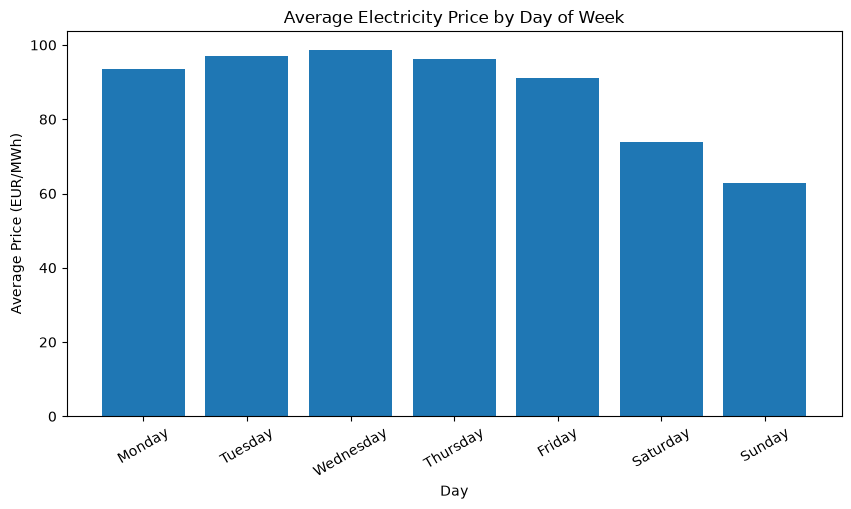

In [131]:
weekday_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_names,
    weekday_profile.values
)

plt.title("Average Electricity Price by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Price (EUR/MWh)")

plt.xticks(rotation=30)

plt.show()

# Heatmap: Stunde × Wochentag

In [101]:
price_heatmap = df.pivot_table(
    values="price",
    index="hour",
    columns="weekday",
    aggfunc="mean"
)

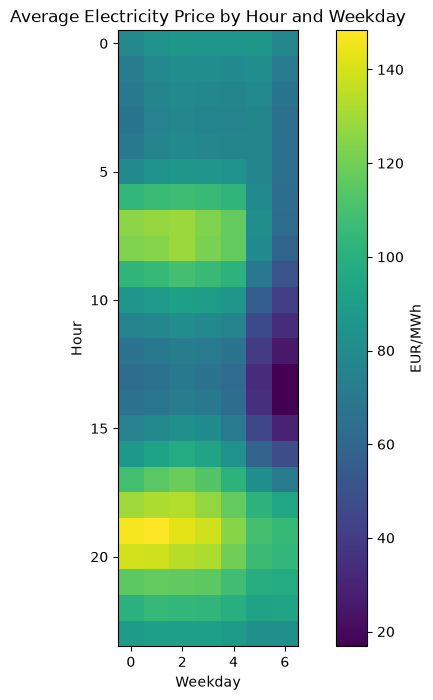

In [102]:
plt.figure(figsize=(10, 8))

plt.imshow(price_heatmap)

plt.title("Average Electricity Price by Hour and Weekday")
plt.xlabel("Weekday")
plt.ylabel("Hour")

plt.colorbar(label="EUR/MWh")

plt.show()

# Monatlich Saisonalität

In [103]:
df["month"] = df["timestamp"].dt.month

In [104]:
monthly_price = (
    df.groupby("month")["price"]
    .mean()
)

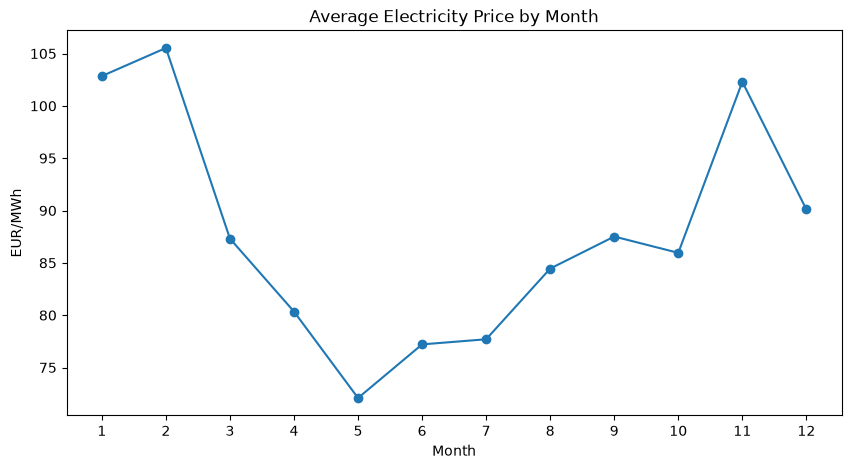

In [105]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_price.index,
    monthly_price.values,
    marker="o"
)

plt.title("Average Electricity Price by Month")
plt.xlabel("Month")
plt.ylabel("EUR/MWh")

plt.xticks(range(1, 13))

plt.show()

# Korrelationen 

In [106]:
correlation = df[
    [
        "price",
        "wind",
        "solar",
        "load"
    ]
].corr()

correlation.round(3)

,price,wind,solar,load
price,1.000,-0.352,-0.431,0.323
wind,-0.352,1.000,-0.260,0.160
solar,-0.431,-0.260,1.000,0.189
load,0.323,0.160,0.189,1.000


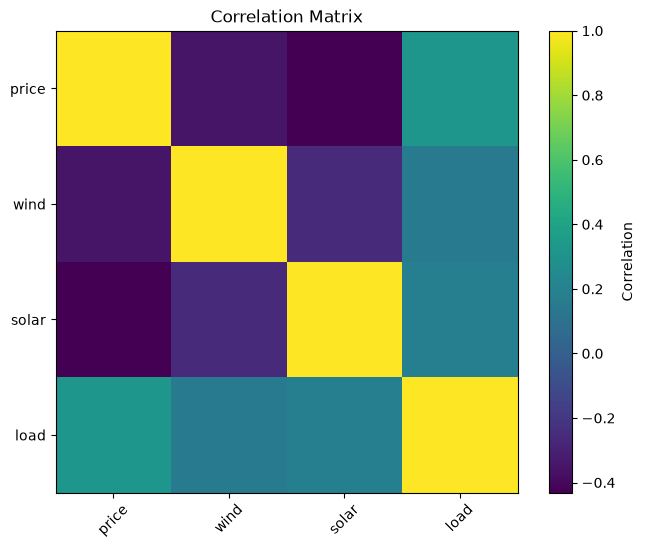

In [107]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix")

plt.show()

# Preis vs erneuerbare Enerie

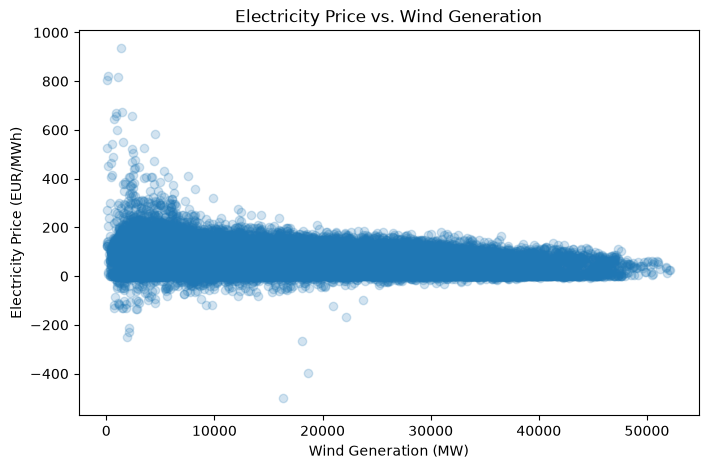

In [108]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["wind"],
    df["price"],
    alpha=0.2
)

plt.xlabel("Wind Generation (MW)")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Price vs. Wind Generation")

plt.show()

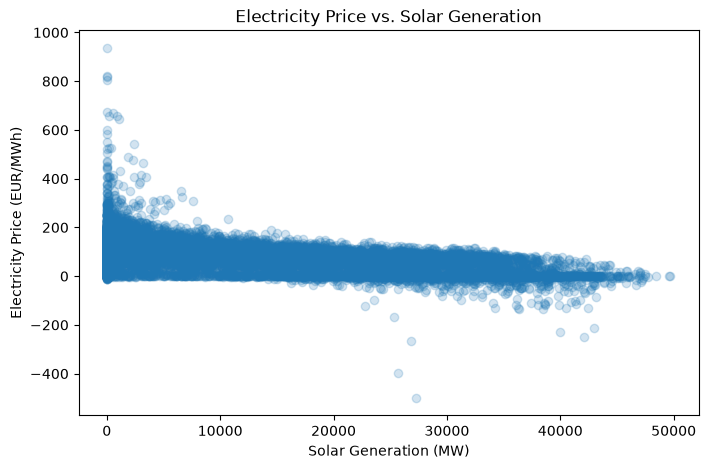

In [109]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["solar"],
    df["price"],
    alpha=0.2
)

plt.xlabel("Solar Generation (MW)")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Price vs. Solar Generation")

plt.show()

# Autokorrelation des Strompreises 
wir wollen vergleichen: 
1. vorherige Stunde
2. gleicher Zeitpunkt am Vortag
3. gleicher Zeitpunkt in der Vorwoche 

In [110]:
df["price_lag_1"] = df["price"].shift(1)
df["price_lag_24"] = df["price"].shift(24)
df["price_lag_168"] = df["price"].shift(168)

In [119]:
print(
    df[[
        "price",
        "price_lag_1",
        "price_lag_24",
        "price_lag_168"
    ]].corr().round(3)
)

               price  price_lag_1  price_lag_24  price_lag_168
price          1.000        0.922         0.669          0.513
price_lag_1    0.922        1.000         0.633          0.474
price_lag_24   0.669        0.633         1.000          0.449
price_lag_168  0.513        0.474         0.449          1.000


Es scheint eine starke Zeitliche Abhängigkeit vorzuliegen. Für diese 3 überprüfugnen weisen die Preise auf kurzfristige, tägliche und wöchentliche zeitliche Strukturen in den Strompreisens hin 

<Figure size 1400x500 with 0 Axes>

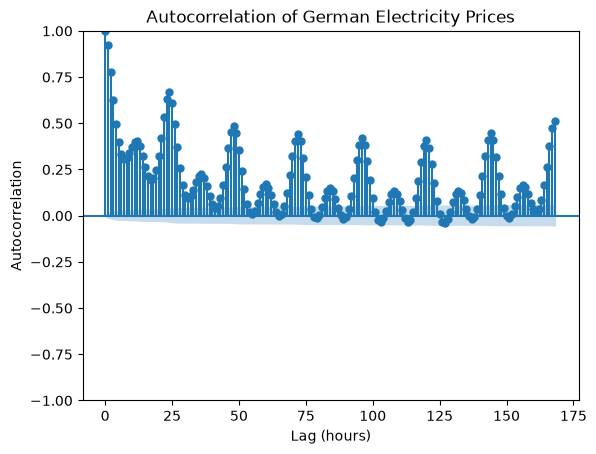

In [123]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 5))

plot_acf(
    df["price"],
    lags=168,
    alpha=0.05
)

plt.title("Autocorrelation of German Electricity Prices")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")

plt.show()

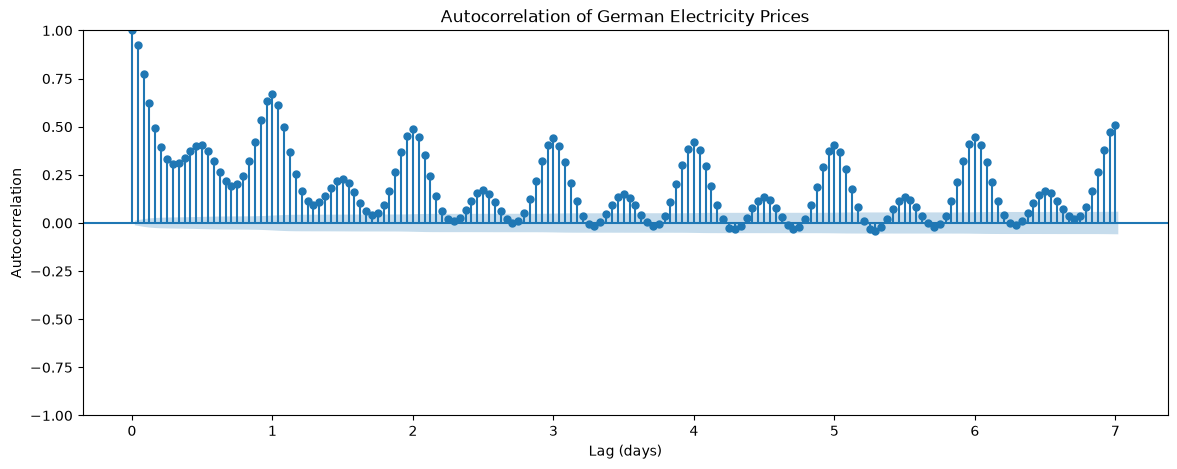

In [124]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    df["price"],
    lags=168,
    alpha=0.05,
    ax=ax
)

# Stunden → Tage
ticks = range(0, 169, 24)
ax.set_xticks(ticks)
ax.set_xticklabels([int(t / 24) for t in ticks])

ax.set_title("Autocorrelation of German Electricity Prices")
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")

plt.show()

In [125]:
lags = [1, 24, 48, 72, 96, 120, 144, 168]

acf_values = [
    df["price"].autocorr(lag=lag)
    for lag in lags
]

for lag, acf in zip(lags, acf_values):
    print(f"{lag:3d} Stunden ({lag/24:.1f} Tage): {acf:.3f}")

  1 Stunden (0.0 Tage): 0.922
 24 Stunden (1.0 Tage): 0.669
 48 Stunden (2.0 Tage): 0.489
 72 Stunden (3.0 Tage): 0.441
 96 Stunden (4.0 Tage): 0.419
120 Stunden (5.0 Tage): 0.409
144 Stunden (6.0 Tage): 0.449
168 Stunden (7.0 Tage): 0.513


# Genauere Untersuchung der Preisspitzen 